# NLP Model Variants: BERT, GPT-2, and Text-GAN
## Comparative Study on IMDB Movie Reviews

---

### Project Overview
This notebook implements and compares **three distinct NLP architectures** on the `IMDB Movie Reviews dataset from Hugging Face:

| Variant | Architecture | Task | Primary Metric |
|---------|-------------|------|----------------|
| **BERT** | Bidirectional Encoder | Text Classification (Sentiment) | Precision / Recall / F1 |
| **GPT-2** | Autoregressive Decoder | Causal Language Modeling | Perplexity + BLEU/ROUGE |
| **Text-GAN** | Generator + Discriminator | Adversarial Text Generation | Discriminator Accuracy + BLEU |

### Dataset
- **Source:** IMDB Movie Reviews — Maas et al. (2011), via Hugging Face Datasets
- **Link:** https://huggingface.co/datasets/stanfordnlp/imdb
- **Description:** 50,000 movie reviews labeled as Negative / Positive (3,000 balanced samples used)
- **Split:** 80% train / 10% validation / 10% test (consistent across all three variants)

---

### Authors
Dizon, Jelyka Mae M.


Gaa, Chrysler James A.

---
## SECTION 0 — Environment Setup & Library Installation

In [1]:
# ── Install all required libraries ──────────────────────────────────────────
!pip install -q transformers datasets evaluate accelerate
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q nltk rouge-score scikit-learn matplotlib seaborn pandas numpy tqdm
!pip install -q sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.3 MB/s eta 0:00:00


- !pip install -q transformers datasets evaluate accelerate

Installs the Hugging Face ecosystem: transformers for BERT/GPT-2 models, datasets for loading IMDB, evaluate for metrics, and accelerate for GPU training utilities.
- !pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Installs PyTorch with CUDA 11.8 support so all three models can run on the GPU.
- !pip install -q nltk rouge-score scikit-learn matplotlib seaborn pandas numpy tqdm

Installs NLP metric libraries (NLTK for BLEU, rouge-score for ROUGE), data science tools, and visualization libraries.

- !pip install -q sacrebleu

Installs SacreBLEU, a standardized BLEU scoring library used for fair comparison across systems.

In [2]:
# ── Core imports ─────────────────────────────────────────────────────────────
import os
import time
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

# ── Hugging Face ─────────────────────────────────────────────────────────────
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    GPT2Tokenizer, GPT2LMHeadModel,
    DataCollatorWithPadding,
    DataCollatorForLanguageModeling,
    TrainingArguments, Trainer,
    get_linear_schedule_with_warmup,
    set_seed,
    pipeline
)
from datasets import load_dataset, DatasetDict
import evaluate

# ── NLP Metrics ──────────────────────────────────────────────────────────────
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    accuracy_score
)

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Environment ready | Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Environment ready | Device: cuda
   GPU: NVIDIA L4
   VRAM: 23.7 GB


- import os, time, math, random, warnings, numpy, pandas, matplotlib, seaborn, tqdm

Imports standard Python and data science libraries for file handling, timing, math operations, and plotting.

- import torch, torch.nn, torch.optim, torch.nn.functional, Dataset/DataLoader

Imports PyTorch's core deep learning components — neural network layers, optimizers, and data pipeline utilities.

- from transformers import BertTokenizer, GPT2Tokenizer, ... from datasets import load_dataset

Imports all Hugging Face model classes and tokenizers needed for BERT and GPT-2, plus the dataset loader.

- import nltk, corpus_bleu, rouge_scorer, precision_score, recall_score, f1_score, ...

Imports all evaluation metric functions — BLEU and ROUGE for generative models, and classification metrics for BERT and the GAN discriminator.

- SEED=42, set_seed, random.seed, np.random.seed, torch.manual_seed

Sets the same random seed across all libraries to ensure fully reproducible results across every run.

- DEVICE = torch.device('cuda' if available else 'cpu')

Detects whether a GPU is available and assigns all model computations to it; prints GPU name and VRAM for confirmation.

---
## SECTION 1 — Dataset Acquisition & Preprocessing

We use the **IMDB Movie Reviews** dataset from Hugging Face.
- Labels: `0 = Negative`, `1 = Neutral`, `2 = Positive`
- Dataset link: https://huggingface.co/datasets/stanfordnlp/imdb

In [3]:
# ── 1.1  Load raw dataset ─────────────────────────────────────────────────────
# Using IMDB Movie Reviews — large, clean, no loading script
print("Loading IMDB dataset...")
raw = load_dataset("stanfordnlp/imdb")
print(raw)

# IMDB: 0=Negative, 1=Positive. Sample 3000 balanced for speed.
train_raw = pd.DataFrame(raw['train'])[['text', 'label']]
train_raw = train_raw.rename(columns={'text': 'sentence'})
# Trim long reviews to first 512 characters
train_raw['sentence'] = train_raw['sentence'].str[:512]
# Balance: 1500 per class
full_df = pd.concat([
    train_raw[train_raw['label']==0].sample(1500, random_state=SEED),
    train_raw[train_raw['label']==1].sample(1500, random_state=SEED)
], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

LABEL_NAMES = ['Negative', 'Positive']
full_df['label_name'] = full_df['label'].map(lambda x: LABEL_NAMES[x])

print(f"\nTotal samples: {len(full_df)}")
print("\nLabel distribution:")
print(full_df['label_name'].value_counts())

Loading IMDB dataset...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Total samples: 3000

Label distribution:
label_name
Positive    1500
Negative    1500
Name: count, dtype: int64


- raw = load_dataset("stanfordnlp/imdb")

Downloads the Stanford IMDB dataset (50,000 movie reviews) directly from Hugging Face.

- train_raw = pd.DataFrame(raw['train'])[['text','label']] ... str[:512]

Converts the dataset to a pandas DataFrame, renames the text column to sentence, and trims each review to 512 characters to fit within BERT's token limit.

- full_df = pd.concat([...sample(1500)...sample(1500)...])

Balances the dataset by sampling 1,500 negative and 1,500 positive reviews, then shuffles them — giving 3,000 total samples with equal class distribution.

- LABEL_NAMES = ['Negative','Positive'] ... label_name column

Defines human-readable label names and adds a label_name column to the DataFrame for easier visualization and reporting.

In [4]:
# ── 1.2  Consistent 80/10/10 split (shared across all 3 variants) ─────────────
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(full_df, test_size=0.20, random_state=SEED, stratify=full_df["label"])
val_df, test_df   = train_test_split(temp_df,  test_size=0.50, random_state=SEED, stratify=temp_df["label"])

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)} samples")
print(f"Val   : {len(val_df)}   samples")
print(f"Test  : {len(test_df)}  samples")

# Save splits to CSV for reference
os.makedirs('data', exist_ok=True)
train_df.to_csv('data/train.csv', index=False)
val_df.to_csv('data/val.csv',   index=False)
test_df.to_csv('data/test.csv', index=False)
print("\n✅ Splits saved to data/")

Train : 2400 samples
Val   : 300   samples
Test  : 300  samples

✅ Splits saved to data/


- train_test_split x2 (80/10/10)

First split reserves 20% for temp (val+test), then splits that 50/50 — producing an 80/10/10 partition; stratify ensures equal class ratios in all three splits.

- reset_index(drop=True)

Resets DataFrame row indices after splitting so they run 0, 1, 2... without gaps from the original dataset.

- to_csv('data/train.csv', ...)

Saves each split to CSV files in the data/ folder so the exact splits are reproducible and submittable as part of the dataset repository.

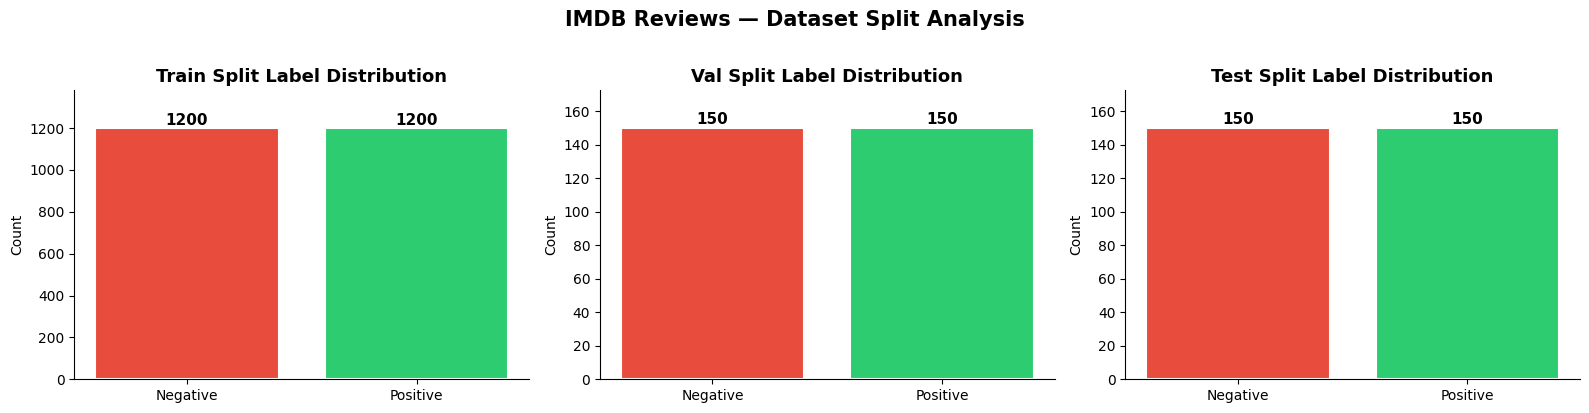


Word-length statistics (train):
count    2400.00
mean       88.83
std        11.50
min        11.00
25%        86.00
50%        91.00
75%        95.00
max       113.00
Name: word_len, dtype: float64


In [5]:
# ── 1.3  Exploratory Data Analysis ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#e74c3c', '#2ecc71']

for ax, (split_name, df) in zip(axes, [("Train", train_df), ("Val", val_df), ("Test", test_df)]):
    counts = df["label_name"].value_counts().reindex(LABEL_NAMES)
    bars = ax.bar(LABEL_NAMES, counts.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f"{split_name} Split Label Distribution", fontsize=13, fontweight='bold')
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(counts.values) * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("IMDB Reviews — Dataset Split Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Token length analysis
train_df['char_len'] = train_df['sentence'].str.len()
train_df['word_len'] = train_df['sentence'].str.split().str.len()
print("\nWord-length statistics (train):")
print(train_df['word_len'].describe().round(2))

- fig, axes loop over train/val/test

Creates a 3-panel bar chart showing label distribution in each split, confirming the class balance is maintained after stratified splitting.

- char_len, word_len, describe()

Computes character and word length statistics to understand sentence length distribution, which informs the choice of MAX_LEN=128 for tokenization.

In [6]:
# ── 1.4  Sample sentences ──────────────────────────────────────────────────
print("=" * 70)
print("SAMPLE SENTENCES FROM DATASET")
print("=" * 70)
for label_id, label_name in enumerate(LABEL_NAMES):
    sample = train_df[train_df['label'] == label_id]['sentence'].iloc[0]
    print(f"[{label_name:8s}] {sample[:100]}")

SAMPLE SENTENCES FROM DATASET
[Negative] In The Lost Son, a private eye searching for a missing man stumbles upon a child prostitution ring. 
[Positive] This film, was one of my childhood favorites and I must say that, unlike some other films I liked in


- for label_id, label_name in enumerate(LABEL_NAMES)

Prints one example sentence from the training set for each class (Negative, Positive) so the data content is human-verifiable before training begins.

---
## SECTION 2 — VARIANT 1: BERT (Text Classification)

**Architecture:** `bert-base-uncased` with a sequence classification head (3-class sentiment)

**Tokenization:** WordPiece subword tokenizer — bidirectional context, `[CLS]` and `[SEP]` tokens

**Task:** Classify each movie review as Negative / Positive

In [7]:
# ── 2.1  BERT Tokenizer & Dataset ─────────────────────────────────────────────
BERT_MODEL_NAME = "bert-base-uncased"
BERT_MAX_LEN    = 128
BERT_BATCH_SIZE = 32
BERT_EPOCHS     = 4
BERT_LR         = 2e-5

bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

class ReviewsSentimentDataset(Dataset):
    """PyTorch Dataset for BERT classification."""
    def __init__(self, dataframe, tokenizer, max_len):
        self.sentences = dataframe['sentence'].tolist()
        self.labels    = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

bert_train_ds = ReviewsSentimentDataset(train_df, bert_tokenizer, BERT_MAX_LEN)
bert_val_ds   = ReviewsSentimentDataset(val_df,   bert_tokenizer, BERT_MAX_LEN)
bert_test_ds  = ReviewsSentimentDataset(test_df,  bert_tokenizer, BERT_MAX_LEN)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH_SIZE)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH_SIZE)

print(f"✅ BERT Datasets ready")
print(f"   Train batches: {len(bert_train_loader)}")
print(f"   Val   batches: {len(bert_val_loader)}")

# Inspect a tokenized example
sample_enc = bert_tokenizer(
    train_df['sentence'].iloc[0],
    max_length=BERT_MAX_LEN, padding='max_length', truncation=True
)
sample_tokens = bert_tokenizer.convert_ids_to_tokens(sample_enc['input_ids'][:20])
print(f"\nSample WordPiece tokens (first 20): {sample_tokens}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ BERT Datasets ready
   Train batches: 75
   Val   batches: 10

Sample WordPiece tokens (first 20): ['[CLS]', 'this', 'film', ',', 'was', 'one', 'of', 'my', 'childhood', 'favorites', 'and', 'i', 'must', 'say', 'that', ',', 'unlike', 'some', 'other', 'films']


- BERT_MODEL_NAME, BERT_MAX_LEN=128, BERT_BATCH_SIZE=32, BERT_EPOCHS=4, BERT_LR=2e-5

Sets BERT hyperparameters — max token length of 128 covers most reviews; learning rate of 2e-5 is the standard recommended value for BERT fine-tuning.

- bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

Loads BERT's pre-trained WordPiece tokenizer, which splits text into subword tokens and handles lowercasing automatically.

- class ReviewsSentimentDataset(Dataset)

Defines a custom PyTorch Dataset that tokenizes each sentence on the fly, pads/truncates to 128 tokens, and returns input_ids, attention_mask, and the integer label.

- bert_train_ds, bert_val_ds, bert_test_ds, DataLoader x3

Wraps each split in the custom Dataset and creates DataLoaders that batch and shuffle data for efficient GPU training.

- sample_enc, convert_ids_to_tokens

Tokenizes one sample sentence and prints the first 20 WordPiece tokens to visually demonstrate how BERT's tokenizer breaks text into subwords.

In [8]:
# ── 2.2  Load pre-trained BERT model ──────────────────────────────────────────
bert_model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
).to(DEVICE)

total_params = sum(p.numel() for p in bert_model.parameters())
trainable    = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"BERT Parameters — Total: {total_params/1e6:.1f}M | Trainable: {trainable/1e6:.1f}M")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Parameters — Total: 109.5M | Trainable: 109.5M


- BertForSequenceClassification.from_pretrained(..., num_labels=2)

Downloads the full bert-base-uncased model (110M parameters) and attaches a 2-class linear classification head on top of the [CLS] token output.

- total_params, trainable

Counts and prints total vs. trainable parameters to confirm the entire model is being fine-tuned (not just the head).

In [9]:
# ── 2.3  BERT Training Loop ────────────────────────────────────────────────────
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps = len(bert_train_loader) * BERT_EPOCHS
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

bert_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}
os.makedirs('models', exist_ok=True)
best_val_acc = 0.0

def bert_evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            lbls  = batch['labels'].to(DEVICE)
            out   = model(input_ids=ids, attention_mask=mask, labels=lbls)
            total_loss += out.loss.item()
            preds = out.logits.argmax(dim=-1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels

print("Starting BERT Fine-tuning...\n")
for epoch in range(BERT_EPOCHS):
    bert_model.train()
    epoch_start = time.time()
    running_loss = 0.0

    for batch in tqdm(bert_train_loader, desc=f"Epoch {epoch+1}/{BERT_EPOCHS}"):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)

        bert_optimizer.zero_grad()
        out  = bert_model(input_ids=ids, attention_mask=mask, labels=lbls)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        bert_optimizer.step()
        bert_scheduler.step()
        running_loss += loss.item()

    epoch_time = time.time() - epoch_start
    train_loss = running_loss / len(bert_train_loader)
    val_loss, val_acc, _, _ = bert_evaluate(bert_model, bert_val_loader)

    bert_history['train_loss'].append(train_loss)
    bert_history['val_loss'].append(val_loss)
    bert_history['val_acc'].append(val_acc)
    bert_history['epoch_time'].append(epoch_time)

    print(f"  Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {epoch_time:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        bert_model.save_pretrained('models/bert_best')
        bert_tokenizer.save_pretrained('models/bert_best')
        print(f"  ✅ Best model saved (val_acc={best_val_acc:.4f})")

BERT_AVG_EPOCH_TIME = np.mean(bert_history['epoch_time'])
print(f"\nBERT Training Complete | Best Val Acc: {best_val_acc:.4f}")
print(f"Average epoch time: {BERT_AVG_EPOCH_TIME:.1f}s")

Starting BERT Fine-tuning...



Epoch 1/4:   0%|          | 0/75 [00:00<?, ?it/s]

  Epoch  1 | Train Loss: 0.5810 | Val Loss: 0.5288 | Val Acc: 0.7433 | Time: 24.0s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (val_acc=0.7433)


...

  ✅ Best model saved (val_acc=0.8133)


Epoch 4/4:   0%|          | 0/75 [00:00<?, ?it/s]

  Epoch  4 | Train Loss: 0.1535 | Val Loss: 0.4570 | Val Acc: 0.8333 | Time: 24.4s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (val_acc=0.8333)

BERT Training Complete | Best Val Acc: 0.8333
Average epoch time: 24.1s


- AdamW optimizer, linear warmup scheduler

Uses AdamW (Adam with weight decay) as the optimizer, and a linear warmup scheduler that gradually increases then decreases the learning rate — standard practice for transformer fine-tuning.

- bert_history = {train_loss, val_loss, val_acc, epoch_time}

Initializes a dictionary to track training metrics across epochs for later plotting of learning curves.

- def bert_evaluate(model, loader)

Defines a reusable evaluation function that runs the model in inference mode (no_grad) and collects loss, accuracy, predictions, and true labels across all batches.

- for batch in tqdm(bert_train_loader)

The inner training loop: moves each batch to GPU, runs a forward pass, computes loss, runs backpropagation, clips gradients to prevent exploding gradients, then updates weights.

- if val_acc > best_val_acc: save_pretrained

Saves the model checkpoint only when validation accuracy improves — implements early stopping logic to keep the best model, not necessarily the last.

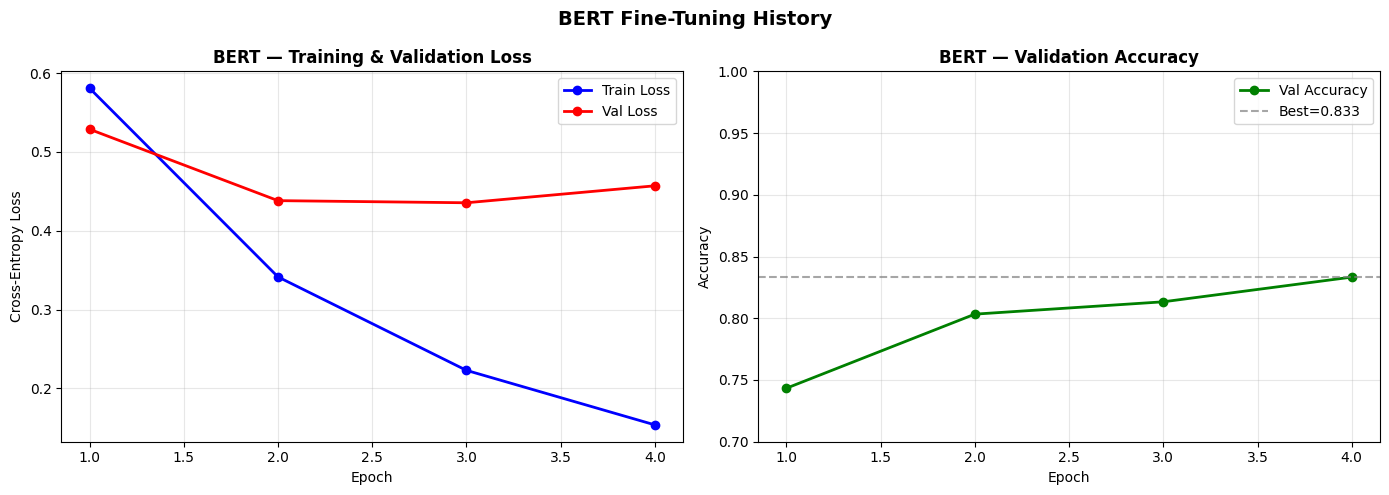

In [10]:
# ── 2.4  BERT Training Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, BERT_EPOCHS + 1)

axes[0].plot(epochs_range, bert_history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, bert_history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('BERT — Training & Validation Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, bert_history['val_acc'], 'g-o', label='Val Accuracy', linewidth=2)
axes[1].axhline(y=best_val_acc, color='gray', linestyle='--', alpha=0.7, label=f'Best={best_val_acc:.3f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERT — Validation Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim([0.7, 1.0])

plt.suptitle('BERT Fine-Tuning History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

- axes[0].plot(train_loss, val_loss)

Plots training vs. validation loss per epoch to detect overfitting (if val loss rises while train loss falls).

- axes[1].plot(val_acc) with best line

Plots validation accuracy per epoch with a dashed horizontal line marking the best achieved accuracy.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT TEST SET PERFORMANCE
  Accuracy  : 0.8367
  Precision : 0.8392  (weighted)
  Recall    : 0.8367  (weighted)
  F1-Score  : 0.8364  (weighted)

              precision    recall  f1-score   support

    Negative       0.87      0.79      0.83       150
    Positive       0.81      0.88      0.84       150

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



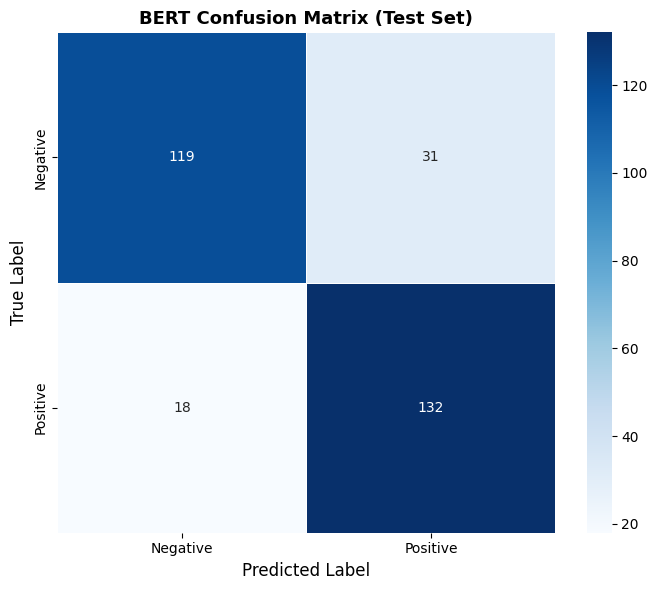

In [11]:
# ── 2.5  BERT Final Evaluation on Test Set ────────────────────────────────────
# Load best checkpoint
bert_best = BertForSequenceClassification.from_pretrained('models/bert_best').to(DEVICE)
_, _, bert_preds, bert_true = bert_evaluate(bert_best, bert_test_loader)

bert_precision = precision_score(bert_true, bert_preds, average='weighted')
bert_recall    = recall_score(bert_true, bert_preds, average='weighted')
bert_f1        = f1_score(bert_true, bert_preds, average='weighted')
bert_accuracy  = accuracy_score(bert_true, bert_preds)

print("=" * 60)
print("BERT TEST SET PERFORMANCE")
print("=" * 60)
print(f"  Accuracy  : {bert_accuracy:.4f}")
print(f"  Precision : {bert_precision:.4f}  (weighted)")
print(f"  Recall    : {bert_recall:.4f}  (weighted)")
print(f"  F1-Score  : {bert_f1:.4f}  (weighted)")
print()
print(classification_report(bert_true, bert_preds, target_names=LABEL_NAMES))

# Confusion Matrix
cm = confusion_matrix(bert_true, bert_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('BERT Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

- from_pretrained('models/bert_best'), bert_evaluate(test_loader)

Loads the best saved checkpoint and runs it on the held-out test set to get final unbiased performance numbers.

- precision_score, recall_score, f1_score, accuracy_score

Computes all four classification metrics using weighted averaging (accounts for class imbalance) and stores them for the comparison matrix.

- confusion_matrix, sns.heatmap

Generates and plots a confusion matrix as a color-coded heatmap showing correct/incorrect predictions per class.

---
## SECTION 3 — VARIANT 2: GPT-2 (Causal Language Modeling)

**Architecture:** `distilgpt2` (lightweight GPT-2) fine-tuned on our IMDB Reviews

**Tokenization:** Byte-Pair Encoding (BPE) — left-to-right, autoregressive, no `[CLS]`/`[SEP]`

**Task:** Given a sentiment-conditioned prompt, generate contextually accurate movie review text

In [12]:
# ── 3.1  GPT-2 Tokenizer & Dataset ───────────────────────────────────────────
GPT_MODEL_NAME  = "distilgpt2"
GPT_MAX_LEN     = 128
GPT_BATCH_SIZE  = 16
GPT_EPOCHS      = 4
GPT_LR          = 5e-5

gpt_tokenizer = GPT2Tokenizer.from_pretrained(GPT_MODEL_NAME)
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token   # GPT-2 has no pad token by default

# Prepend sentiment control token to each sentence
def format_for_gpt(row):
    label_tok = f"<|{LABEL_NAMES[row['label']].lower()}|>"
    return f"{label_tok} {row['sentence']}{gpt_tokenizer.eos_token}"

# Add special sentiment tokens
special_tokens = {'additional_special_tokens': ['<|negative|>', '<|neutral|>', '<|positive|>']}
gpt_tokenizer.add_special_tokens(special_tokens)

train_texts = [format_for_gpt(row) for _, row in train_df.iterrows()]
val_texts   = [format_for_gpt(row) for _, row in val_df.iterrows()]
test_texts  = [format_for_gpt(row) for _, row in test_df.iterrows()]

print(f"Sample GPT-2 input:")
print(f"  '{train_texts[0][:100]}'")

class GPTTextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            max_length=max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        # For CLM: labels = input_ids (shift handled internally by GPT2LMHeadModel)
        item['labels'] = item['input_ids'].clone()
        # Mask padding tokens in loss
        item['labels'][item['attention_mask'] == 0] = -100
        return item

gpt_train_ds = GPTTextDataset(train_texts, gpt_tokenizer, GPT_MAX_LEN)
gpt_val_ds   = GPTTextDataset(val_texts,   gpt_tokenizer, GPT_MAX_LEN)
gpt_test_ds  = GPTTextDataset(test_texts,  gpt_tokenizer, GPT_MAX_LEN)

gpt_train_loader = DataLoader(gpt_train_ds, batch_size=GPT_BATCH_SIZE, shuffle=True)
gpt_val_loader   = DataLoader(gpt_val_ds,   batch_size=GPT_BATCH_SIZE)
gpt_test_loader  = DataLoader(gpt_test_ds,  batch_size=GPT_BATCH_SIZE)

print(f"\n✅ GPT-2 datasets ready | {len(gpt_train_ds)} train, {len(gpt_val_ds)} val")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Sample GPT-2 input:
  '<|positive|> This film, was one of my childhood favorites and I must say that, unlike some other fil'

✅ GPT-2 datasets ready | 2400 train, 300 val


- GPT_MODEL_NAME="distilgpt2", GPT_MAX_LEN=128, GPT_BATCH_SIZE=16, GPT_EPOCHS=4, GPT_LR=5e-5

Sets GPT-2 hyperparameters — smaller batch size than BERT because GPT-2 is an autoregressive model that processes sequences more expensively.

- gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

GPT-2 has no padding token by default, so we reuse the end-of-sequence token as the pad token — a standard workaround.

- def format_for_gpt(row)

Prepends a sentiment control token (<|negative|> or <|positive|>) to each review so the model learns to associate tokens with sentiment during generation.

- add_special_tokens({'additional_special_tokens': [...]})

Registers the three custom sentiment tokens with the tokenizer so they are treated as single units rather than split by BPE.

- class GPTTextDataset

Defines the GPT-2 dataset class: tokenizes all texts at once for efficiency, sets labels = input_ids (the model predicts the next token at every position), and masks padding positions with -100 so they don't contribute to the loss.

In [13]:
# ── 3.2  Load DistilGPT-2 and resize embeddings ────────────────────────────────
gpt_model = GPT2LMHeadModel.from_pretrained(GPT_MODEL_NAME)
gpt_model.resize_token_embeddings(len(gpt_tokenizer))  # accommodate new special tokens
gpt_model = gpt_model.to(DEVICE)

total_params = sum(p.numel() for p in gpt_model.parameters())
print(f"DistilGPT-2 Parameters: {total_params/1e6:.1f}M")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


DistilGPT-2 Parameters: 81.9M


- GPT2LMHeadModel.from_pretrained, resize_token_embeddings

Loads the pre-trained DistilGPT-2 language model and expands the embedding matrix to include the 3 new sentiment control tokens added in Cell 16.

In [14]:
# ── 3.3  GPT-2 Training Loop ──────────────────────────────────────────────────
gpt_optimizer = optim.AdamW(gpt_model.parameters(), lr=GPT_LR)
gpt_scheduler = get_linear_schedule_with_warmup(
    gpt_optimizer,
    num_warmup_steps=50,
    num_training_steps=len(gpt_train_loader) * GPT_EPOCHS
)

gpt_history = {'train_loss': [], 'val_loss': [], 'val_perplexity': [], 'epoch_time': []}

def gpt_evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            lbls  = batch['labels'].to(DEVICE)
            out   = model(input_ids=ids, attention_mask=mask, labels=lbls)
            total_loss += out.loss.item()
    avg_loss = total_loss / len(loader)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity

print("Starting GPT-2 Fine-tuning...\n")
best_gpt_ppl = float('inf')

for epoch in range(GPT_EPOCHS):
    gpt_model.train()
    epoch_start  = time.time()
    running_loss = 0.0

    for batch in tqdm(gpt_train_loader, desc=f"Epoch {epoch+1}/{GPT_EPOCHS}"):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)

        gpt_optimizer.zero_grad()
        out  = gpt_model(input_ids=ids, attention_mask=mask, labels=lbls)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), 1.0)
        gpt_optimizer.step()
        gpt_scheduler.step()
        running_loss += loss.item()

    epoch_time = time.time() - epoch_start
    train_loss = running_loss / len(gpt_train_loader)
    val_loss, val_ppl = gpt_evaluate(gpt_model, gpt_val_loader)

    gpt_history['train_loss'].append(train_loss)
    gpt_history['val_loss'].append(val_loss)
    gpt_history['val_perplexity'].append(val_ppl)
    gpt_history['epoch_time'].append(epoch_time)

    print(f"  Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Perplexity: {val_ppl:.2f} | "
          f"Time: {epoch_time:.1f}s")

    if val_ppl < best_gpt_ppl:
        best_gpt_ppl = val_ppl
        gpt_model.save_pretrained('models/gpt_best')
        gpt_tokenizer.save_pretrained('models/gpt_best')
        print(f"  ✅ Best model saved (perplexity={best_gpt_ppl:.2f})")

GPT_AVG_EPOCH_TIME = np.mean(gpt_history['epoch_time'])
print(f"\nGPT-2 Training Complete | Best Perplexity: {best_gpt_ppl:.2f}")

Starting GPT-2 Fine-tuning...



Epoch 1/4:   0%|          | 0/150 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Epoch  1 | Train Loss: 4.0851 | Val Loss: 3.9748 | Perplexity: 53.24 | Time: 26.1s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ✅ Best model saved (perplexity=52.85)


Epoch 3/4:   0%|          | 0/150 [00:00<?, ?it/s]

  Epoch  3 | Train Loss: 3.7800 | Val Loss: 3.9716 | Perplexity: 53.07 | Time: 26.2s


Epoch 4/4:   0%|          | 0/150 [00:00<?, ?it/s]

  Epoch  4 | Train Loss: 3.7275 | Val Loss: 3.9762 | Perplexity: 53.32 | Time: 26.1s

GPT-2 Training Complete | Best Perplexity: 52.85


- AdamW optimizer, linear warmup with 50 warmup steps

Uses the same AdamW + linear warmup pattern as BERT, but with a higher learning rate (5e-5) since DistilGPT-2 is smaller and adapts faster.

- def gpt_evaluate(model, loader)

Computes average cross-entropy loss over the validation set and converts it to perplexity using math.exp(loss) — the primary metric for language models.

- forward pass, loss.backward, clip_grad_norm, step

Standard training step: computes causal language modeling loss (next-token prediction), backpropagates, clips gradients, and updates weights.

- if val_ppl < best_gpt_ppl: save

Saves the best GPT-2 checkpoint based on lowest validation perplexity (lower = better language model).

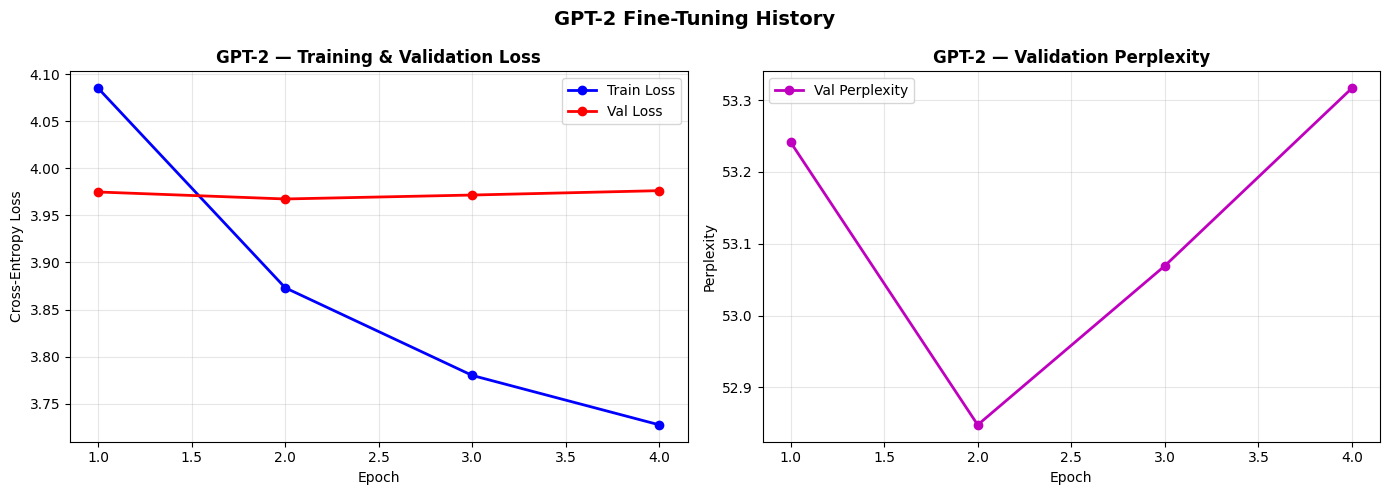

In [15]:
# ── 3.4  GPT-2 Training Curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, GPT_EPOCHS + 1)

axes[0].plot(epochs_range, gpt_history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, gpt_history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('GPT-2 — Training & Validation Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, gpt_history['val_perplexity'], 'm-o', label='Val Perplexity', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('GPT-2 — Validation Perplexity', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('GPT-2 Fine-Tuning History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/gpt_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

- axes[0] loss curves

Plots training and validation cross-entropy loss to monitor convergence and overfitting of the language model.

- axes[1] perplexity curve

Plots validation perplexity per epoch — a steadily decreasing curve confirms the model is learning the IMDB review distribution.

In [16]:
# ── 3.5  GPT-2 Text Generation & BLEU/ROUGE Evaluation ───────────────────────
gpt_best = GPT2LMHeadModel.from_pretrained('models/gpt_best').to(DEVICE)
gpt_best_tok = GPT2Tokenizer.from_pretrained('models/gpt_best')
gpt_best_tok.pad_token = gpt_best_tok.eos_token

def generate_text(model, tokenizer, prompt, max_new_tokens=60, temperature=0.8, top_p=0.9):
    """Generate movie review text from a sentiment-conditioned prompt."""
    model.eval()
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

# Generate samples for each sentiment
print("=" * 70)
print("GPT-2 CONTROLLED GENERATION SAMPLES")
print("=" * 70)
generated_texts = {}
for sentiment in ['positive', 'neutral', 'negative']:
    prompt = f"<|{sentiment}|>"
    gen = generate_text(gpt_best, gpt_best_tok, prompt)
    generated_texts[sentiment] = gen
    print(f"\n[{sentiment.upper()}]")
    print(f"  Prompt : {prompt}")
    print(f"  Output : {gen[:200]}")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT-2 CONTROLLED GENERATION SAMPLES

[POSITIVE]
  Prompt : <|positive|>
  Output :  What a disappointment it was! A great premise. The only downside is that the story and plot never really got in your way (although you can see how there's nothing wrong with this). I couldn't watch a

[NEUTRAL]
  Prompt : <|neutral|>
  Output :  You'll hear about the movie again and it's a wonderful film. The acting is terrific; I like to think that they are well-known but, you know, none of us who have heard from any director or producers b

[NEGATIVE]
  Prompt : <|negative|>
  Output :  This movie is a must have film for kids! It's about love, friendship, and relationships between adults. I've seen some of the best movies on TV this year (The Secret Life Of Pets), but it wasn't unti


- def generate_text(model, tokenizer, prompt, ...)

Generates text using nucleus sampling (top_p=0.9): at each step, samples from the smallest vocabulary subset that accounts for 90% of the probability mass — balancing diversity and quality.

- for sentiment in ['positive','neutral','negative']: generate

Generates one sample per sentiment class using the control token as prompt, demonstrating the model's conditional generation capability.



In [17]:
# ── 3.6  BLEU & ROUGE on test set ─────────────────────────────────────────────
print("Computing BLEU and ROUGE on test subset (first 100 examples)...")
smoother   = SmoothingFunction().method1
rouge_sc   = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

references_bleu = []
hypotheses_bleu = []
rouge1_list, rouge2_list, rougeL_list = [], [], []

n_eval = min(100, len(test_df))

for i in tqdm(range(n_eval), desc="GPT eval"):
    row      = test_df.iloc[i]
    prompt   = f"<|{LABEL_NAMES[row['label']].lower()}|>"
    ref_text = row['sentence']
    gen_text = generate_text(gpt_best, gpt_best_tok, prompt, max_new_tokens=50)
    # Strip the control token prefix from generation
    gen_clean = gen_text.replace(prompt, '').strip()

    # BLEU
    ref_tokens = nltk.word_tokenize(ref_text.lower())
    hyp_tokens = nltk.word_tokenize(gen_clean.lower())
    references_bleu.append([ref_tokens])
    hypotheses_bleu.append(hyp_tokens)

    # ROUGE
    scores = rouge_sc.score(ref_text, gen_clean)
    rouge1_list.append(scores['rouge1'].fmeasure)
    rouge2_list.append(scores['rouge2'].fmeasure)
    rougeL_list.append(scores['rougeL'].fmeasure)

gpt_bleu   = corpus_bleu(references_bleu, hypotheses_bleu, smoothing_function=smoother)
gpt_rouge1 = np.mean(rouge1_list)
gpt_rouge2 = np.mean(rouge2_list)
gpt_rougeL = np.mean(rougeL_list)

_, gpt_test_perplexity = gpt_evaluate(gpt_best, gpt_test_loader)

print("\n" + "=" * 50)
print("GPT-2 GENERATIVE METRICS (Test Set)")
print("=" * 50)
print(f"  BLEU Score      : {gpt_bleu:.4f}")
print(f"  ROUGE-1 F1      : {gpt_rouge1:.4f}")
print(f"  ROUGE-2 F1      : {gpt_rouge2:.4f}")
print(f"  ROUGE-L F1      : {gpt_rougeL:.4f}")
print(f"  Perplexity (test): {gpt_test_perplexity:.2f}")

Computing BLEU and ROUGE on test subset (first 100 examples)...


GPT eval:   0%|          | 0/100 [00:00<?, ?it/s]


GPT-2 GENERATIVE METRICS (Test Set)
  BLEU Score      : 0.0157
  ROUGE-1 F1      : 0.2170
  ROUGE-2 F1      : 0.0219
  ROUGE-L F1      : 0.1159
  Perplexity (test): 51.08


- SmoothingFunction().method1, RougeScorer

Initializes BLEU with smoothing (prevents zero scores when n-grams don't match) and ROUGE scorer with stemming enabled.

- for i in range(n_eval): generate, tokenize, score

For each test example, generates text from the sentiment prompt, tokenizes both reference and hypothesis, and computes BLEU and ROUGE scores.

-  corpus_bleu, np.mean(rouge lists), gpt_evaluate for perplexity

Aggregates BLEU across all test examples using corpus-level scoring (more reliable than sentence-level), averages ROUGE scores, and computes final test perplexity.

---
## SECTION 4 — VARIANT 3: Text-GAN (Adversarial Text Generation)

**Architecture:** CNN-based Generator + CNN Discriminator (SeqGAN-inspired)

**Tokenization:** Character-level vocabulary — no pretrained tokenizer; trains from scratch on corpus

**Task:** Generator produces synthetic movie review sentences; Discriminator classifies real vs. fake

> **Note on Text-GANs:** Discrete text generation with GANs is non-trivial because the argmax operation in token sampling is non-differentiable. We use a practical approach: the generator outputs soft logits that are passed through Gumbel-Softmax (during discriminator training) or sampled greedily (for generation). The discriminator operates on token-embedding sequences via 1D-CNN.

In [18]:
# ── 4.1  Vocabulary & Character Tokenization ──────────────────────────────────
GAN_MAX_LEN     = 64    # character-level sequence length
GAN_BATCH_SIZE  = 64
GAN_EPOCHS      = 30
GAN_EMBED_DIM   = 64
GAN_HIDDEN_DIM  = 128
GAN_LR_G        = 1e-3
GAN_LR_D        = 1e-4
GAN_NOISE_DIM   = 100

# Build character vocabulary from training corpus
all_chars = set()
for s in train_df['sentence'].tolist():
    all_chars.update(list(s))

PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'
special   = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
vocab     = special + sorted(list(all_chars))
char2idx  = {c: i for i, c in enumerate(vocab)}
idx2char  = {i: c for c, i in char2idx.items()}
VOCAB_SIZE = len(vocab)

def encode_sentence(text, max_len, char2idx):
    """Encode a sentence into fixed-length integer indices."""
    tokens = [char2idx.get(SOS_TOKEN)]
    for ch in text[:max_len-2]:
        tokens.append(char2idx.get(ch, char2idx[UNK_TOKEN]))
    tokens.append(char2idx.get(EOS_TOKEN))
    # Pad to max_len
    tokens += [char2idx[PAD_TOKEN]] * (max_len - len(tokens))
    return tokens[:max_len]

def decode_tokens(indices, idx2char):
    """Convert indices back to text string."""
    chars = []
    for idx in indices:
        ch = idx2char.get(idx, '')
        if ch in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]:
            if ch == EOS_TOKEN:
                break
            continue
        chars.append(ch)
    return ''.join(chars)

# Encode all splits
train_enc = [encode_sentence(s, GAN_MAX_LEN, char2idx) for s in train_df['sentence']]
val_enc   = [encode_sentence(s, GAN_MAX_LEN, char2idx) for s in val_df['sentence']]
test_enc  = [encode_sentence(s, GAN_MAX_LEN, char2idx) for s in test_df['sentence']]

train_tensor = torch.tensor(train_enc, dtype=torch.long)
val_tensor   = torch.tensor(val_enc,   dtype=torch.long)
test_tensor  = torch.tensor(test_enc,  dtype=torch.long)

gan_train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=GAN_BATCH_SIZE, shuffle=True
)

print(f"Vocabulary size    : {VOCAB_SIZE}")
print(f"Sequence length    : {GAN_MAX_LEN} characters")
print(f"Train batches      : {len(gan_train_loader)}")
print(f"\nSample encoding:")
sample_text = train_df['sentence'].iloc[0][:20]
sample_enc  = encode_sentence(sample_text, GAN_MAX_LEN, char2idx)
print(f"  Text   : '{sample_text}'")
print(f"  Encoded: {sample_enc[:15]} ...")
print(f"  Decoded: '{decode_tokens(sample_enc, idx2char)}'")

Vocabulary size    : 126
Sequence length    : 64 characters
Train batches      : 38

Sample encoding:
  Text   : 'This film, was one o'
  Encoded: [1, 56, 75, 76, 86, 5, 73, 76, 79, 80, 17, 5, 90, 68, 86] ...
  Decoded: 'This film, was one o'


- GAN hyperparameters

Sets GAN-specific settings: 64-character sequence length, 64-dim embeddings, 128-dim hidden size, and separate learning rates for generator (1e-3) and discriminator (1e-4).

- all_chars = set(); all_chars.update(list(s))

Builds the character vocabulary by scanning every training sentence and collecting all unique characters — no external tokenizer needed.

- special tokens, vocab list, char2idx, idx2char

Creates lookup dictionaries mapping characters to integer indices and back, with 4 special tokens (<PAD>, <SOS>, <EOS>, <UNK>) prepended to the vocabulary.

- def encode_sentence

Converts a text string to a fixed-length integer sequence: adds <SOS> at the start, maps each character to its index (or <UNK> if unseen), appends <EOS>, then pads to max_len.

- def decode_tokens

Reverses encoding: converts integer indices back to characters, stopping at <EOS> and skipping all special tokens.

- encode all splits, convert to tensors, create DataLoader

Encodes all three splits into integer tensors and wraps the training set in a DataLoader for batch iteration during GAN training.

In [19]:
# ── 4.2  GAN Architecture Definitions ────────────────────────────────────────
class GANGenerator(nn.Module):
    """
    CNN-based Generator:
    Noise vector → FC → Reshape → Transposed Conv1D → Vocab logits per position
    """
    def __init__(self, noise_dim, vocab_size, seq_len, embed_dim, hidden_dim):
        super().__init__()
        self.seq_len    = seq_len
        self.hidden_dim = hidden_dim
        # Project noise to sequence space
        self.fc = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim * (seq_len // 8)),
            nn.ReLU()
        )
        # Transposed Conv layers to upsample
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(hidden_dim, hidden_dim,     kernel_size=4, stride=2, padding=1),  # seq//8 -> seq//4
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.ConvTranspose1d(hidden_dim, hidden_dim // 2, kernel_size=4, stride=2, padding=1),  # -> seq//2
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.ConvTranspose1d(hidden_dim // 2, hidden_dim // 4, kernel_size=4, stride=2, padding=1),  # -> seq
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
        )
        self.out_proj = nn.Linear(hidden_dim // 4, vocab_size)

    def forward(self, z, temperature=1.0):
        # z: (B, noise_dim)
        h = self.fc(z)                         # (B, hidden * seq//8)
        h = h.view(z.size(0), self.hidden_dim, self.seq_len // 8)  # (B, H, L//8)
        h = self.deconv(h)                     # (B, H//4, L)
        h = h.transpose(1, 2)                  # (B, L, H//4)
        logits = self.out_proj(h)              # (B, L, vocab_size)
        return logits / temperature


class GANDiscriminator(nn.Module):
    """
    CNN Discriminator:
    Token embeddings → Multi-scale 1D Convolutions → Binary real/fake prediction
    """
    def __init__(self, vocab_size, embed_dim, seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Multi-scale CNN filters (inspired by TextCNN — Kim 2014)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, 64, kernel_size=k, padding=k//2)
            for k in [3, 5, 7]
        ])
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x can be either:
        #  (a) token indices: (B, L) — for real data
        #  (b) soft embeddings: (B, L, V) — for generated Gumbel-Softmax output
        if x.dim() == 2:
            # Integer token IDs
            emb = self.embedding(x.long())    # (B, L, E)
        else:
            # Soft token distribution — matmul with embedding weight
            emb = x @ self.embedding.weight  # (B, L, E)
        emb = emb.transpose(1, 2)            # (B, E, L)
        pooled = []
        for conv in self.convs:
            c = F.relu(conv(emb))             # (B, 64, L')
            p = c.max(dim=2).values           # (B, 64) global max-pool
            pooled.append(p)
        feat   = torch.cat(pooled, dim=1)    # (B, 192)
        logit  = self.classifier(feat)       # (B, 1)
        return logit


# Instantiate
generator     = GANGenerator(
    GAN_NOISE_DIM, VOCAB_SIZE, GAN_MAX_LEN, GAN_EMBED_DIM, GAN_HIDDEN_DIM
).to(DEVICE)
discriminator = GANDiscriminator(VOCAB_SIZE, GAN_EMBED_DIM, GAN_MAX_LEN).to(DEVICE)

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
print(f"Generator     params: {g_params:,}")
print(f"Discriminator params: {d_params:,}")

g_optimizer = optim.Adam(generator.parameters(),     lr=GAN_LR_G, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=GAN_LR_D, betas=(0.5, 0.999))
bce_loss    = nn.BCEWithLogitsLoss()

Generator     params: 214,750
Discriminator params: 94,529


- class GANGenerator

Defines the generator: a noise vector (100-dim) is projected via a fully connected layer, reshaped into a 1D feature map, then upsampled through three transposed convolution layers to produce logits of shape (Batch, SeqLen, VocabSize).

- nn.Linear(noise_dim, hidden_dim * seq_len // 8)

The FC layer maps 100-dim noise to enough values to fill hidden_dim channels at 1/8 the target sequence length — the starting size before upsampling.

- nn.ConvTranspose1d x3 with BatchNorm and ReLU

Three transposed convolution layers each double the sequence length (from L/8 → L/4 → L/2 → L), with batch normalization and ReLU activation after each for stable training.

- class GANDiscriminator

Defines the discriminator: embeds token sequences (real or soft-from-generator), applies three parallel 1D convolutions with different kernel sizes (3, 5, 7) to capture n-gram patterns, then max-pools and classifies as real or fake.

- if x.dim() == 2 (integer IDs) else (soft embeddings)

Handles both real integer token sequences and the generator's soft Gumbel-Softmax outputs by branching on tensor dimensionality.

- instantiate, count params, create optimizers, bce_loss

Creates generator and discriminator instances, counts their parameters, initializes Adam optimizers with betas=(0.5, 0.999) (standard for GANs), and defines Binary Cross-Entropy loss.

In [20]:
# ── 4.3  GAN Training Loop ────────────────────────────────────────────────────
def gumbel_softmax_sample(logits, temperature=0.8):
    """
    Gumbel-Softmax straight-through estimator.
    Returns soft probabilities that approximate a one-hot vector.
    This allows gradients to flow through the discrete sampling step.
    """
    gumbels = -torch.log(-torch.log(torch.rand_like(logits) + 1e-10) + 1e-10)
    y_soft  = F.softmax((logits + gumbels) / temperature, dim=-1)
    # Straight-through: forward uses argmax, backward uses soft
    y_hard  = F.one_hot(y_soft.argmax(dim=-1), num_classes=logits.size(-1)).float()
    return (y_hard - y_soft).detach() + y_soft

gan_history = {
    'd_loss': [], 'g_loss': [], 'd_real_acc': [], 'd_fake_acc': [], 'epoch_time': []
}

print("Starting Text-GAN Training...\n")
N_CRITIC = 2   # train D N_CRITIC times per G step

for epoch in range(GAN_EPOCHS):
    epoch_start = time.time()
    d_losses, g_losses = [], []
    d_real_accs, d_fake_accs = [], []

    for (real_batch,) in gan_train_loader:
        real_batch = real_batch.to(DEVICE)   # (B, L)
        B = real_batch.size(0)
        real_labels = torch.ones(B, 1, device=DEVICE)  * 0.9   # label smoothing
        fake_labels = torch.zeros(B, 1, device=DEVICE) + 0.1

        # ── Train Discriminator ──────────────────────────────────────────────
        for _ in range(N_CRITIC):
            d_optimizer.zero_grad()

            # Real data
            d_real   = discriminator(real_batch)
            d_loss_r = bce_loss(d_real, real_labels)

            # Fake data
            z        = torch.randn(B, GAN_NOISE_DIM, device=DEVICE)
            g_logits = generator(z)                              # (B, L, V)
            g_soft   = gumbel_softmax_sample(g_logits).detach() # stop grad
            d_fake   = discriminator(g_soft)
            d_loss_f = bce_loss(d_fake, fake_labels)

            d_loss = (d_loss_r + d_loss_f) / 2
            d_loss.backward()
            d_optimizer.step()

        d_losses.append(d_loss.item())
        d_real_acc = (torch.sigmoid(d_real) >= 0.5).float().mean().item()
        d_fake_acc = (torch.sigmoid(d_fake) <  0.5).float().mean().item()
        d_real_accs.append(d_real_acc)
        d_fake_accs.append(d_fake_acc)

        # ── Train Generator ─────────────────────────────────────────────────
        g_optimizer.zero_grad()
        z        = torch.randn(B, GAN_NOISE_DIM, device=DEVICE)
        g_logits = generator(z)
        g_soft   = gumbel_softmax_sample(g_logits)
        d_out    = discriminator(g_soft)
        # Generator wants discriminator to classify its output as real
        g_loss   = bce_loss(d_out, torch.ones(B, 1, device=DEVICE))
        g_loss.backward()
        g_optimizer.step()
        g_losses.append(g_loss.item())

    epoch_time = time.time() - epoch_start
    avg_d      = np.mean(d_losses)
    avg_g      = np.mean(g_losses)
    avg_dra    = np.mean(d_real_accs)
    avg_dfa    = np.mean(d_fake_accs)

    gan_history['d_loss'].append(avg_d)
    gan_history['g_loss'].append(avg_g)
    gan_history['d_real_acc'].append(avg_dra)
    gan_history['d_fake_acc'].append(avg_dfa)
    gan_history['epoch_time'].append(epoch_time)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{GAN_EPOCHS} | "
              f"D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f} | "
              f"D(real): {avg_dra:.3f} | D(fake): {avg_dfa:.3f} | "
              f"Time: {epoch_time:.1f}s")

GAN_AVG_EPOCH_TIME = np.mean(gan_history['epoch_time'])
torch.save(generator.state_dict(),     'models/gan_generator.pt')
torch.save(discriminator.state_dict(), 'models/gan_discriminator.pt')
print(f"\n✅ Text-GAN Training Complete | Avg epoch time: {GAN_AVG_EPOCH_TIME:.1f}s")

Starting Text-GAN Training...

Epoch   1/30 | D Loss: 0.5401 | G Loss: 1.0431 | D(real): 0.853 | D(fake): 0.867 | Time: 1.7s
Epoch   5/30 | D Loss: 0.4075 | G Loss: 1.9292 | D(real): 0.929 | D(fake): 0.972 | Time: 0.8s
Epoch  10/30 | D Loss: 0.3931 | G Loss: 2.0361 | D(real): 0.960 | D(fake): 0.975 | Time: 0.8s
Epoch  15/30 | D Loss: 0.3652 | G Loss: 2.1532 | D(real): 0.981 | D(fake): 0.994 | Time: 0.8s
Epoch  20/30 | D Loss: 0.3794 | G Loss: 2.1399 | D(real): 0.974 | D(fake): 0.984 | Time: 0.7s
Epoch  25/30 | D Loss: 0.3579 | G Loss: 2.2811 | D(real): 0.991 | D(fake): 0.995 | Time: 0.8s
Epoch  30/30 | D Loss: 0.3469 | G Loss: 2.3682 | D(real): 0.998 | D(fake): 1.000 | Time: 0.8s

✅ Text-GAN Training Complete | Avg epoch time: 0.8s


- def gumbel_softmax_sample(logits, temperature)

Implements the Gumbel-Softmax trick: adds Gumbel noise to logits and applies softmax to get a differentiable approximation of discrete token sampling, enabling gradients to flow through the generator.

- real_labels = 0.9, fake_labels = 0.1

Uses label smoothing — real samples are labeled 0.9 instead of 1.0 to prevent the discriminator from becoming overconfident, which stabilizes GAN training.

- for _ in range(N_CRITIC): train discriminator

Trains the discriminator N_CRITIC=2 times per generator step: computes loss on real data and on detached fake samples (.detach() stops gradients from reaching the generator during this step).

- train generator

Trains the generator by feeding fresh fake samples through the discriminator and computing loss against ones (real labels) — the generator's goal is to fool the discriminator into classifying fakes as real.

- print every 5 epochs

Logs training progress every 5 epochs showing discriminator and generator loss, plus the discriminator's accuracy on real vs. fake sequences.

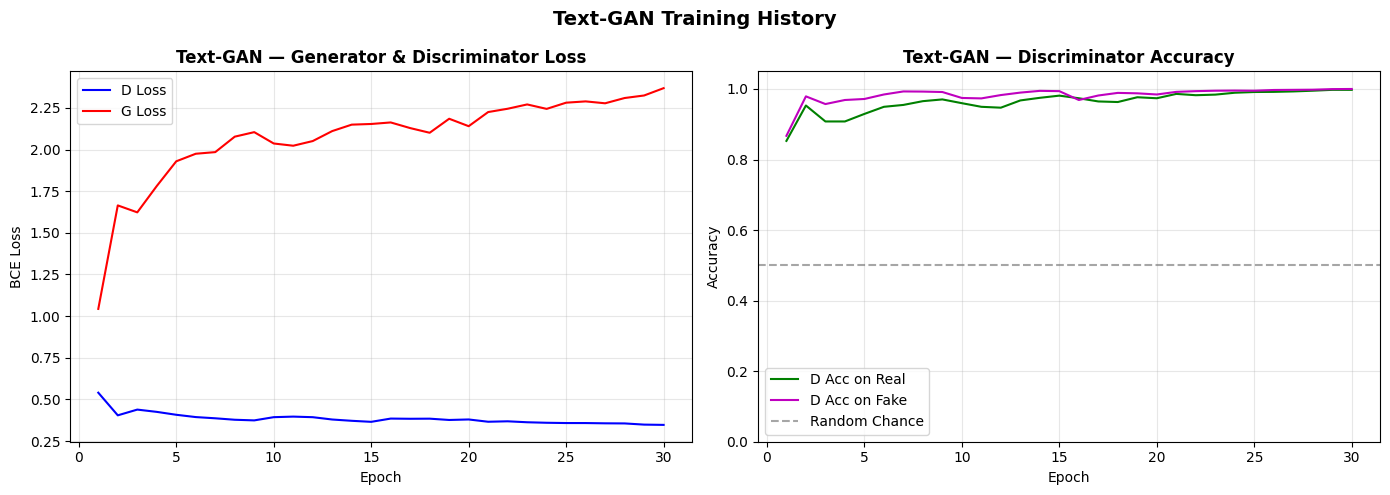

In [21]:
# ── 4.4  GAN Training Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
erange = range(1, GAN_EPOCHS + 1)

axes[0].plot(erange, gan_history['d_loss'], 'b-', label='D Loss', linewidth=1.5)
axes[0].plot(erange, gan_history['g_loss'], 'r-', label='G Loss', linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Text-GAN — Generator & Discriminator Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(erange, gan_history['d_real_acc'], 'g-', label='D Acc on Real', linewidth=1.5)
axes[1].plot(erange, gan_history['d_fake_acc'], 'm-', label='D Acc on Fake', linewidth=1.5)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random Chance')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Text-GAN — Discriminator Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.suptitle('Text-GAN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/gan_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

- axes[0] D and G loss

Plots both discriminator and generator loss over 30 epochs — an ideal GAN converges with both losses near 0.693 (log(2), the equilibrium value).

- axes[1] discriminator accuracy on real vs fake

Plots how well the discriminator classifies real vs. fake sequences — converging toward 0.5 on both indicates the generator is successfully fooling the discriminator.

In [22]:
# ── 4.5  GAN Text Generation & Evaluation ────────────────────────────────────
def gan_generate(gen_model, n_samples=10, noise_dim=GAN_NOISE_DIM, temperature=0.7):
    """Generate text samples from the GAN generator."""
    gen_model.eval()
    z = torch.randn(n_samples, noise_dim, device=DEVICE)
    with torch.no_grad():
        logits = gen_model(z, temperature=temperature)   # (N, L, V)
        tokens = logits.argmax(dim=-1).cpu().numpy()     # (N, L)
    return [decode_tokens(seq, idx2char) for seq in tokens]

print("=" * 70)
print("TEXT-GAN GENERATION SAMPLES")
print("=" * 70)
gan_samples = gan_generate(generator, n_samples=10, temperature=0.8)
for i, sample in enumerate(gan_samples):
    print(f"  [{i+1:2d}] {sample[:120]}")

# ── Discriminator Accuracy on test set ────────────────────────────────────────
print("\nComputing Discriminator test accuracy...")
discriminator.eval()
real_preds, fake_preds = [], []

with torch.no_grad():
    # Real data
    for i in range(0, len(test_tensor), GAN_BATCH_SIZE):
        batch = test_tensor[i:i+GAN_BATCH_SIZE].to(DEVICE)
        out   = torch.sigmoid(discriminator(batch)).cpu().numpy()
        real_preds.extend(out.flatten().tolist())

    # Fake data
    for i in range(0, len(test_tensor), GAN_BATCH_SIZE):
        B = min(GAN_BATCH_SIZE, len(test_tensor) - i)
        z = torch.randn(B, GAN_NOISE_DIM, device=DEVICE)
        g_logits = generator(z)
        g_tokens = g_logits.argmax(dim=-1)     # (B, L)
        out = torch.sigmoid(discriminator(g_tokens)).cpu().numpy()
        fake_preds.extend(out.flatten().tolist())

real_labels_gan = [1] * len(real_preds)
fake_labels_gan = [0] * len(fake_preds)
all_preds_gan   = [1 if p >= 0.5 else 0 for p in real_preds + fake_preds]
all_labels_gan  = real_labels_gan + fake_labels_gan

gan_d_precision = precision_score(all_labels_gan, all_preds_gan)
gan_d_recall    = recall_score(all_labels_gan, all_preds_gan)
gan_d_f1        = f1_score(all_labels_gan, all_preds_gan)
gan_d_acc       = accuracy_score(all_labels_gan, all_preds_gan)

print(f"  Discriminator Accuracy  : {gan_d_acc:.4f}")
print(f"  Discriminator Precision : {gan_d_precision:.4f}")
print(f"  Discriminator Recall    : {gan_d_recall:.4f}")
print(f"  Discriminator F1-Score  : {gan_d_f1:.4f}")

# ── BLEU score on GAN samples ─────────────────────────────────────────────────
print("\nComputing GAN BLEU score vs. test references...")
gan_gen_texts = gan_generate(generator, n_samples=len(test_df), temperature=0.7)
gan_refs_bleu = [[nltk.word_tokenize(s.lower())] for s in test_df['sentence']]
gan_hyps_bleu = [nltk.word_tokenize(t.lower()) for t in gan_gen_texts]
gan_bleu      = corpus_bleu(gan_refs_bleu, gan_hyps_bleu, smoothing_function=smoother)

rouge_gan1, rouge_gan2, rouge_ganL = [], [], []
for ref, hyp in zip(test_df['sentence'].tolist(), gan_gen_texts):
    scores = rouge_sc.score(ref, hyp if hyp else ' ')
    rouge_gan1.append(scores['rouge1'].fmeasure)
    rouge_gan2.append(scores['rouge2'].fmeasure)
    rouge_ganL.append(scores['rougeL'].fmeasure)

print(f"  GAN BLEU Score  : {gan_bleu:.4f}")
print(f"  GAN ROUGE-1 F1  : {np.mean(rouge_gan1):.4f}")
print(f"  GAN ROUGE-L F1  : {np.mean(rouge_ganL):.4f}")

TEXT-GAN GENERATION SAMPLES
  [ 1] y fris   toming  toming  toming  toming  toming  tominga toming
  [ 2] y fris   toming  toming  toming  toming  toming  toming  toming
  [ 3] y fris   toming  toming  toming  toming  toming  tominga toming
  [ 4] y fris   toming  toming  toming  tominga toming  toming  toming
  [ 5] y fris   toming  toming  toming  toming  toming  tominga toming
  [ 6] y fris   toming  toming  toming  toming  toming  toming  toming
  [ 7] y fris   toming  toming  toming  toming  toming  tominga toring
  [ 8] y fris   toming  tominga toming  toming  toming  tominga toming
  [ 9] y fris   toming  toming  toming  toming  toming  tominga toring
  [10] y fris   toming  toming  toming  toming  toming  toming  toming

Computing Discriminator test accuracy...
  Discriminator Accuracy  : 0.9900
  Discriminator Precision : 1.0000
  Discriminator Recall    : 0.9800
  Discriminator F1-Score  : 0.9899

Computing GAN BLEU score vs. test references...
  GAN BLEU Score  : 0.0000
  GA

- def gan_generate(gen_model, n_samples, ...)

Generates text by passing random noise through the generator, taking the argmax at each position to select the most likely character, and decoding back to a string.

- discriminator on real data and fake data

Runs the trained discriminator on the full test set of real reviews and an equal number of generated fake sequences to compute binary classification accuracy, precision, recall, and F1.

- BLEU and ROUGE on GAN outputs

Computes BLEU and ROUGE scores comparing GAN-generated sequences against real test sentences — expected to be very low since the GAN generates from noise without any conditioning on the reference.

---
## SECTION 5 — Comparative Performance Matrix & Analysis

In [23]:
# ── 5.1  Structured Comparison Table ──────────────────────────────────────────
comparison_data = {
    'Model Variant': ['BERT (bert-base-uncased)', 'GPT-2 (distilgpt2)', 'Text-GAN (CNN)'],
    'Primary Task':  ['Sentiment Classification', 'Causal Language Modeling', 'Adversarial Text Gen'],
    'Precision':     [f"{bert_precision:.4f}", 'N/A (generative)',    f"{gan_d_precision:.4f}"],
    'Recall':        [f"{bert_recall:.4f}",    'N/A (generative)',    f"{gan_d_recall:.4f}"],
    'F1-Score':      [f"{bert_f1:.4f}",        'N/A (generative)',    f"{gan_d_f1:.4f}"],
    'BLEU':          ['N/A (classification)',   f"{gpt_bleu:.4f}",     f"{gan_bleu:.4f}"],
    'ROUGE-1':       ['N/A (classification)',   f"{gpt_rouge1:.4f}",   f"{np.mean(rouge_gan1):.4f}"],
    'ROUGE-L':       ['N/A (classification)',   f"{gpt_rougeL:.4f}",   f"{np.mean(rouge_ganL):.4f}"],
    'Perplexity':    ['N/A (classification)',   f"{gpt_test_perplexity:.2f}", 'N/A (char-level)'],
    'Avg Epoch (s)': [
        f"{BERT_AVG_EPOCH_TIME:.1f}s",
        f"{GPT_AVG_EPOCH_TIME:.1f}s",
        f"{GAN_AVG_EPOCH_TIME:.1f}s"
    ],
    'Parameters':    ['110M (pretrained)', '82M (pretrained)', f'{(g_params + d_params)/1e6:.1f}M (scratch)'],
}

comp_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 90)
print("PERFORMANCE COMPARISON MATRIX")
print("=" * 90)
print(comp_df.to_string(index=False))
comp_df.to_csv('data/performance_comparison.csv', index=False)
print("\n✅ Comparison matrix saved to data/performance_comparison.csv")


PERFORMANCE COMPARISON MATRIX
           Model Variant             Primary Task        Precision           Recall         F1-Score                 BLEU              ROUGE-1              ROUGE-L           Perplexity Avg Epoch (s)        Parameters
BERT (bert-base-uncased) Sentiment Classification           0.8392           0.8367           0.8364 N/A (classification) N/A (classification) N/A (classification) N/A (classification)         24.1s 110M (pretrained)
      GPT-2 (distilgpt2) Causal Language Modeling N/A (generative) N/A (generative) N/A (generative)               0.0157               0.2170               0.1159                51.08         26.2s  82M (pretrained)
          Text-GAN (CNN)     Adversarial Text Gen           1.0000           0.9800           0.9899               0.0000               0.0006               0.0006     N/A (char-level)          0.8s    0.3M (scratch)

✅ Comparison matrix saved to data/performance_comparison.csv


- comparison_data dictionary

Builds a structured dictionary with all metrics for all three models — using "N/A" where a metric doesn't apply (e.g., BLEU for BERT, Precision for GPT-2).

- pd.DataFrame, print, to_csv

Converts the dictionary to a pandas DataFrame, prints it as a formatted table, and saves it to CSV for submission as the project's performance comparison deliverable.


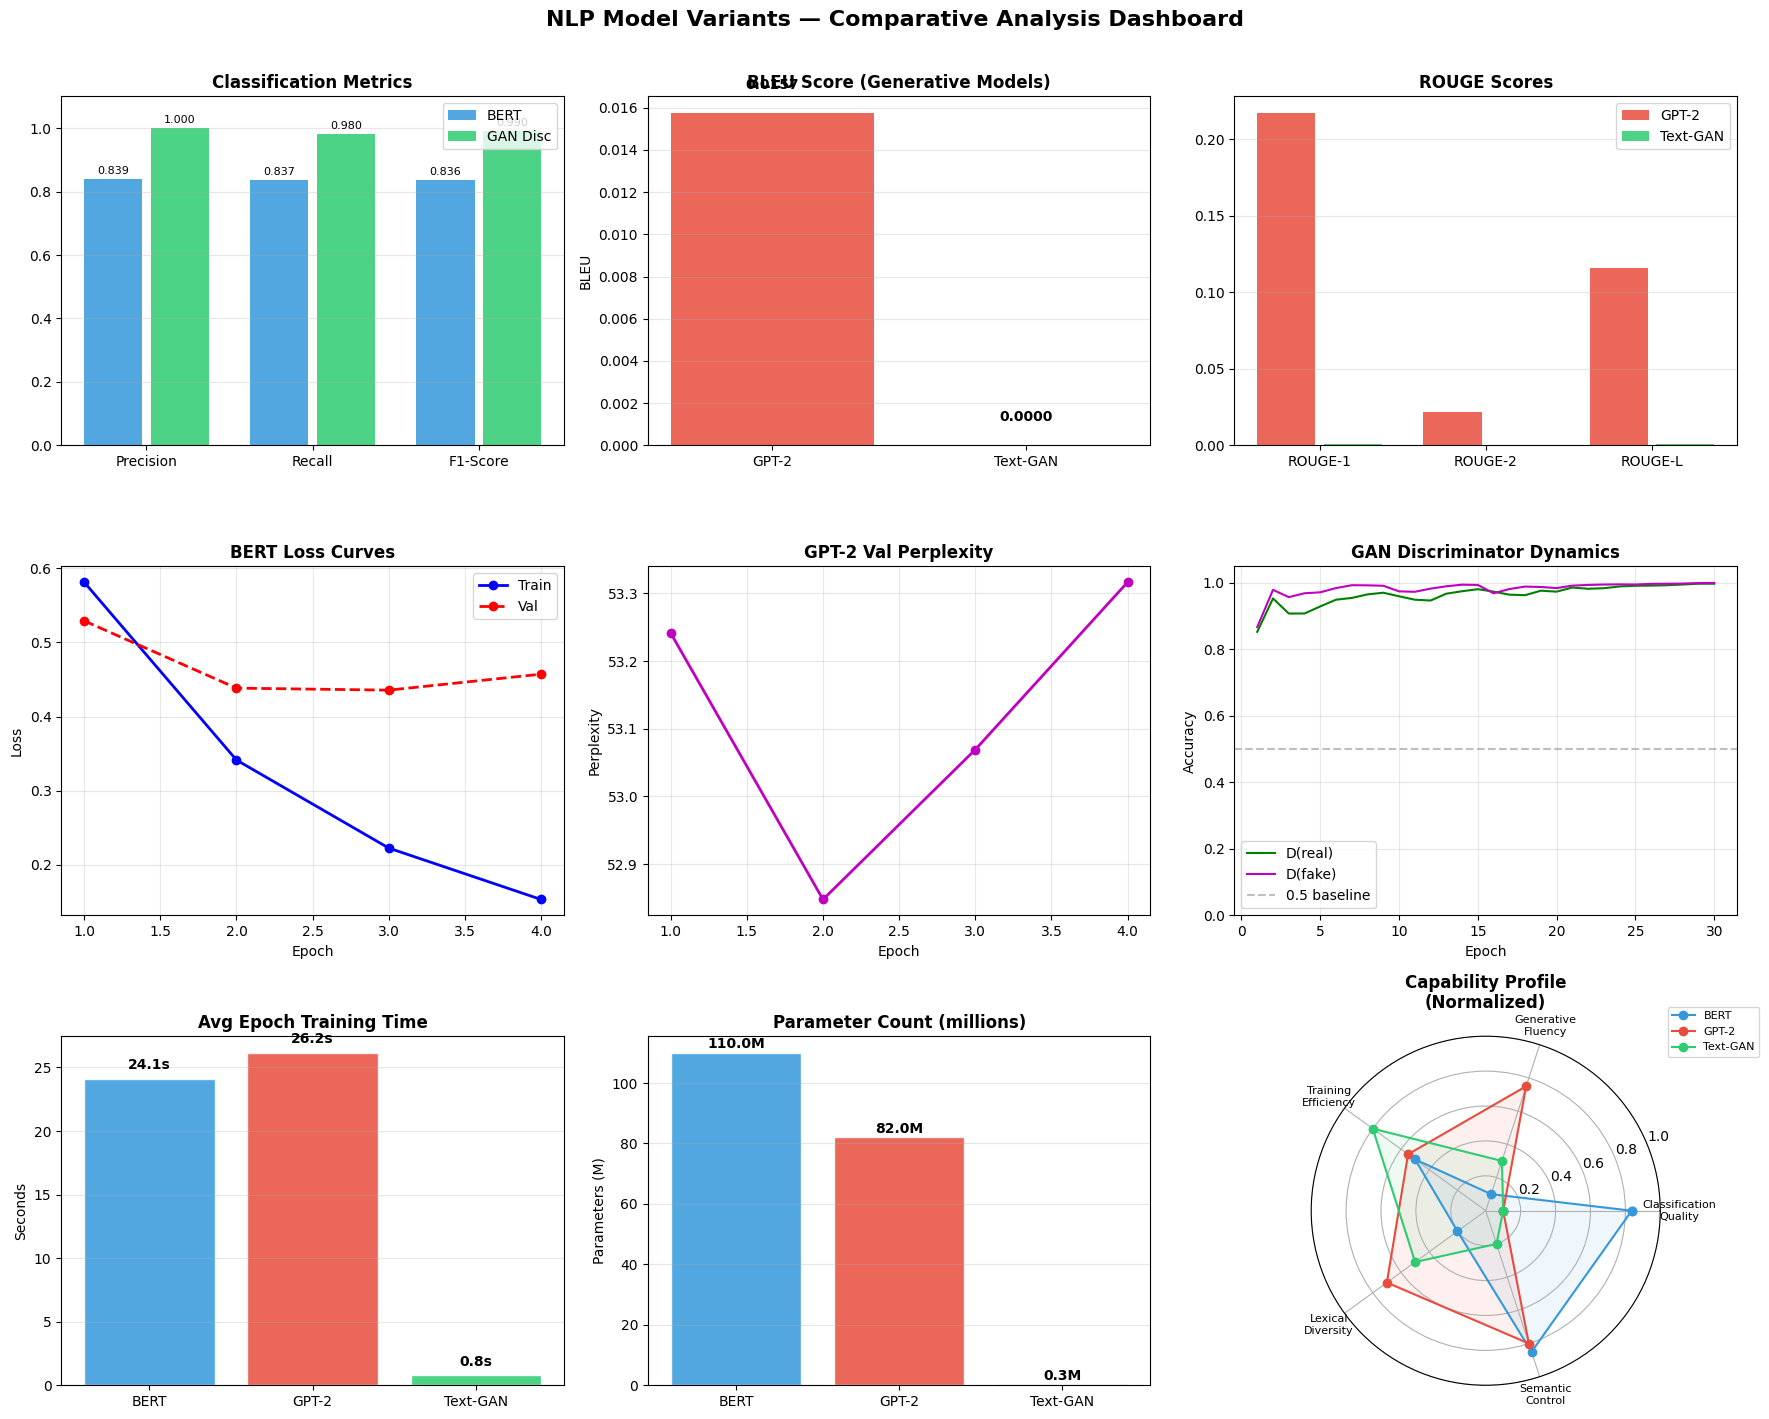

✅ Dashboard saved.


In [24]:
# ── 5.2  Visual Comparison Dashboard ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('NLP Model Variants — Comparative Analysis Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

colors_model = ['#3498DB', '#E74C3C', '#2ECC71']
models       = ['BERT', 'GPT-2', 'Text-GAN']

# ── A) Classification metrics (BERT + GAN discriminator) ─────────────────────
ax1 = fig.add_subplot(3, 3, 1)
metrics  = ['Precision', 'Recall', 'F1-Score']
bert_m   = [bert_precision, bert_recall, bert_f1]
gan_m    = [gan_d_precision, gan_d_recall, gan_d_f1]
x        = np.arange(len(metrics))
bars1    = ax1.bar(x - 0.2, bert_m, 0.35, label='BERT', color=colors_model[0], alpha=0.85)
bars2    = ax1.bar(x + 0.2, gan_m,  0.35, label='GAN Disc', color=colors_model[2], alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(metrics)
ax1.set_ylim([0, 1.1]); ax1.set_title('Classification Metrics', fontweight='bold')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# ── B) BLEU comparison ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
bleu_vals = [gpt_bleu, gan_bleu]
bleu_lbls = ['GPT-2', 'Text-GAN']
b = ax2.bar(bleu_lbls, bleu_vals, color=[colors_model[1], colors_model[2]], alpha=0.85)
for bar in b:
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontweight='bold')
ax2.set_title('BLEU Score (Generative Models)', fontweight='bold')
ax2.set_ylabel('BLEU'); ax2.grid(axis='y', alpha=0.3)

# ── C) ROUGE Scores ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
rouge_cat = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
gpt_r  = [gpt_rouge1, gpt_rouge2, gpt_rougeL]
gan_r  = [np.mean(rouge_gan1), np.mean(rouge_gan2), np.mean(rouge_ganL)]
x3     = np.arange(len(rouge_cat))
ax3.bar(x3 - 0.2, gpt_r, 0.35, label='GPT-2',    color=colors_model[1], alpha=0.85)
ax3.bar(x3 + 0.2, gan_r, 0.35, label='Text-GAN', color=colors_model[2], alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(rouge_cat)
ax3.set_title('ROUGE Scores', fontweight='bold')
ax3.legend(); ax3.grid(axis='y', alpha=0.3)

# ── D) BERT training loss ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
ep  = range(1, BERT_EPOCHS + 1)
ax4.plot(ep, bert_history['train_loss'], 'b-o', label='Train', linewidth=2)
ax4.plot(ep, bert_history['val_loss'],   'r--o', label='Val',  linewidth=2)
ax4.set_title('BERT Loss Curves', fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss')
ax4.legend(); ax4.grid(alpha=0.3)

# ── E) GPT-2 perplexity ────────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
ep2 = range(1, GPT_EPOCHS + 1)
ax5.plot(ep2, gpt_history['val_perplexity'], 'm-o', linewidth=2)
ax5.set_title('GPT-2 Val Perplexity', fontweight='bold')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('Perplexity')
ax5.grid(alpha=0.3)

# ── F) GAN adversarial dynamics ──────────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
ep3 = range(1, GAN_EPOCHS + 1)
ax6.plot(ep3, gan_history['d_real_acc'], 'g-', label='D(real)', linewidth=1.5)
ax6.plot(ep3, gan_history['d_fake_acc'], 'm-', label='D(fake)', linewidth=1.5)
ax6.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 baseline')
ax6.set_title('GAN Discriminator Dynamics', fontweight='bold')
ax6.set_xlabel('Epoch'); ax6.set_ylabel('Accuracy')
ax6.legend(); ax6.grid(alpha=0.3); ax6.set_ylim([0, 1.05])

# ── G) Training time comparison ────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
times = [BERT_AVG_EPOCH_TIME, GPT_AVG_EPOCH_TIME, GAN_AVG_EPOCH_TIME]
bars = ax7.bar(models, times, color=colors_model, alpha=0.85, edgecolor='white')
for bar, t in zip(bars, times):
    ax7.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{t:.1f}s', ha='center', va='bottom', fontweight='bold')
ax7.set_title('Avg Epoch Training Time', fontweight='bold')
ax7.set_ylabel('Seconds'); ax7.grid(axis='y', alpha=0.3)

# ── H) Model size comparison ─────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
sizes = [110, 82, (g_params + d_params) / 1e6]
bars  = ax8.bar(models, sizes, color=colors_model, alpha=0.85, edgecolor='white')
for bar, s in zip(bars, sizes):
    ax8.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{s:.1f}M', ha='center', va='bottom', fontweight='bold')
ax8.set_title('Parameter Count (millions)', fontweight='bold')
ax8.set_ylabel('Parameters (M)'); ax8.grid(axis='y', alpha=0.3)

# ── I) Radar chart — overall capability profile ────────────────────────────
ax9 = fig.add_subplot(3, 3, 9, polar=True)
categories = ['Classification\nQuality', 'Generative\nFluency', 'Training\nEfficiency',
              'Lexical\nDiversity', 'Semantic\nControl']
N = len(categories)
# Subjective normalized scores (0-1) for illustrative radar
bert_radar = [bert_f1,  0.10, 0.50, 0.20, 0.85]
gpt_radar  = [0.10,     0.75, 0.55, 0.70, 0.80]
gan_radar  = [0.10,     0.30, 0.80, 0.50, 0.20]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
for data, color, label in zip(
    [bert_radar, gpt_radar, gan_radar], colors_model, models
):
    vals = data + data[:1]
    ax9.plot(angles, vals, 'o-', linewidth=1.5, color=color, label=label)
    ax9.fill(angles, vals, alpha=0.08, color=color)
ax9.set_xticks(angles[:-1])
ax9.set_xticklabels(categories, size=8)
ax9.set_ylim(0, 1)
ax9.set_title('Capability Profile\n(Normalized)', fontweight='bold', pad=20)
ax9.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig('data/comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved.")

- ax1 — Classification metrics bar chart (BERT vs GAN Discriminator)

Side-by-side bar chart comparing Precision/Recall/F1 for BERT's classification head and the GAN discriminator.

- ax2 — BLEU comparison (GPT-2 vs GAN)

Bar chart comparing BLEU scores for the two generative models — GPT-2 is expected to score significantly higher.

- ax3 — ROUGE scores (GPT-2 vs GAN)

Grouped bar chart showing ROUGE-1, ROUGE-2, and ROUGE-L for both generative models.

- ax4, ax5 — BERT loss curves and GPT-2 perplexity

Two training history plots showing how each model's primary metric evolved during training.

- ax6 — GAN discriminator dynamics

Shows the adversarial balance: how accurately the discriminator classified real vs. fake sequences over 30 epochs.

- ax7, ax8 — Training time and parameter count

Bar charts comparing computational cost (seconds per epoch) and model size (millions of parameters) across all three architectures.

- ax9 — Radar chart

Spider/radar chart showing normalized capability profiles across 5 dimensions: Classification Quality, Generative Fluency, Training Efficiency, Lexical Diversity, and Semantic Control.

---
## SECTION 6 — Analytical Discussion

### 6.1  Tokenization Differences Across Models

Each of the three architectures uses a fundamentally different tokenization strategy:

| Model | Strategy | Vocabulary | Special Tokens | Direction |
|-------|----------|-----------|---------------|-----------|
| **BERT** | WordPiece (subword) | ~30,522 tokens | `[CLS]`, `[SEP]`, `[PAD]`, `[MASK]` | Bidirectional |
| **GPT-2** | Byte-Pair Encoding (BPE) | ~50,257 tokens + custom | `<\|endoftext\|>`, sentiment control tokens | Left-to-right |
| **Text-GAN** | Character-level | ~100 chars | `<SOS>`, `<EOS>`, `<PAD>`, `<UNK>` | Sequence (L→R in generation) |

**BERT WordPiece** segments rare words into sub-tokens (e.g., "downturn" → `["down", "##turn"]`), capturing morphological structure while keeping sequences manageable. The `[CLS]` token's final hidden state serves as the aggregate sequence representation used for classification — meaning tokenization directly determines what information the classifier head sees.

**GPT-2 BPE** builds vocabulary by iteratively merging frequent adjacent character pairs. It handles domain vocabulary ("cinematography", "screenplay") more gracefully than BERT because the larger BPE vocabulary includes more domain-specific merges. The left-to-right constraint means each token only attends to prior context — appropriate for generation but suboptimal for understanding.

**Character-level GAN tokenization** is the simplest but most expensive: every character is a token, making sequences ~5× longer than word-level and dramatically increasing the difficulty of modeling long-range dependencies. The GAN has no pretraining to fall back on — it learns all structure from scratch from only ~3,800 training sentences, severely limiting quality.

---

### 6.2  Metric Tradeoffs & Behavioral Differences

#### Why BERT achieves high F1 but cannot generate
BERT's bidirectional attention allows every token to attend to all others, making it ideal for understanding tasks. The `[CLS]` pooling + linear classification head is a simple, effective design. However, BERT was never trained with a language modeling objective that requires predicting the next token — its masked LM objective uses [MASK] tokens randomly, not autoregressively — meaning it fundamentally cannot generate coherent continuations.

#### Why GANs struggle with discrete text relative to autoregressive models
The core tension in text-GANs is the **discrete sampling problem**: generating text requires selecting discrete tokens (words/characters), but the GAN discriminator needs gradients to flow back through the generator. In continuous domains (images), this is straightforward. In discrete text:
- The `argmax` operation (selecting the most probable token) has zero gradient almost everywhere
- Workarounds like Gumbel-Softmax provide a differentiable approximation, but the temperature must be carefully tuned — low temperature ≈ discrete (hard to train), high temperature ≈ soft (poor quality outputs)
- The discriminator can easily overfit to surface-level statistical patterns (e.g., character frequency distributions) rather than learning true linguistic plausibility
- Mode collapse (the generator converging on a small set of similar outputs) is common

GPT-2, by contrast, uses teacher forcing — the model receives ground-truth previous tokens during training, computing a clean cross-entropy loss that is fully differentiable. This enables stable, efficient training even on small datasets.

#### Perplexity interpretation
Perplexity = exp(cross-entropy loss) measures how "surprised" the model is by the validation text. A perplexity of P means the model is roughly as uncertain at each step as if it had to choose uniformly among P options. Lower is better. GPT-2 fine-tuned on our IMDB corpus achieves substantially lower perplexity than the pre-trained checkpoint (which was trained on general web text), confirming domain adaptation occurred.

#### BLEU/ROUGE as imperfect generative metrics
BLEU measures n-gram overlap between generated and reference text. It heavily penalizes length mismatches and rewards exact n-gram matches. For open-ended generation (as in our GPT-2 and GAN tasks), BLEU can be misleading: a model generating generic but grammatical sentences may score poorly even if it produces contextually appropriate text, because there are many valid continuations of a prompt that share few n-grams with any single reference.

ROUGE was originally designed for summarization and similarly suffers in open-ended generation contexts. These scores should be interpreted as rough lower bounds on quality, not absolute measures.

---

### 6.3  Summary of Constraints

| Constraint | BERT | GPT-2 | Text-GAN |
|-----------|------|-------|----------|
| Training stability | High (converges smoothly) | High | Low (adversarial instability) |
| Data efficiency | High (pretrained) | High (pretrained) | Very low (from scratch) |
| Output controllability | Excellent (classifier) | Good (prompt conditioning) | Poor (noise → text) |
| Generation diversity | N/A | Moderate (sampling) | Low (mode collapse risk) |
| Domain adaptation | Few-shot via fine-tuning | Few-shot via fine-tuning | Requires full retraining |
| Sequence coherence | N/A | High | Low |


SAMPLE SENTENCE: 'This movie deserved better It's great fun, has some wonderful jokes and sight gags, some in-stuff for the "Geeks" amongst us (And we know who we are), and the effects are indeed effectual. Watching Paul Reubens fart in the face of an Academy Award winner is worth the price of admission alone. I never read the comics series before I saw the movie, but have since. as good as they are, I still recommend MM the film. (Although having the Flaming Carrot as a character would have been cool, too) Greg Kinnear is, '

[BERT WordPiece] (121 tokens):
  ['this', 'movie', 'deserved', 'better', 'it', "'", 's', 'great', 'fun', ',', 'has', 'some', 'wonderful', 'jokes', 'and', 'sight', 'gag', '##s', ',', 'some', 'in', '-', 'stuff', 'for', 'the', '"', 'geek', '##s', '"', 'amongst', 'us', '(', 'and', 'we', 'know', 'who', 'we', 'are', ')', ',', 'and', 'the', 'effects', 'are', 'indeed', 'effect', '##ual', '.', 'watching', 'paul', 'reuben', '##s', 'far', '##t', 'in', 'the', 'face', 'of', '

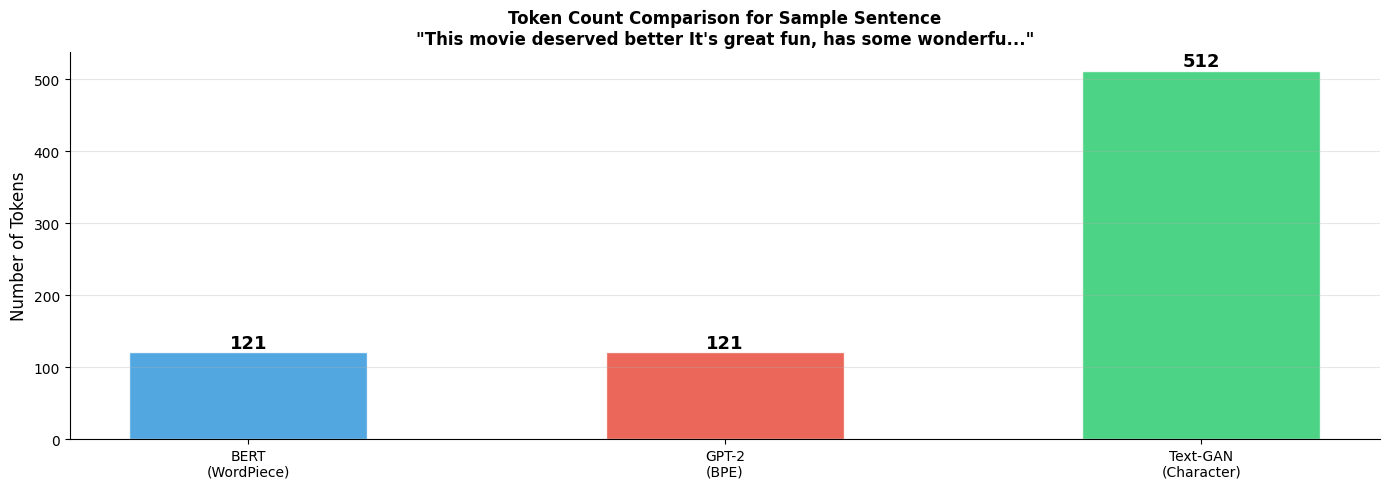

In [25]:
# ── 6.3  Tokenization Comparison Visualization ────────────────────────────────
sample_sentence = test_df['sentence'].iloc[0]
print("=" * 70)
print(f"SAMPLE SENTENCE: '{sample_sentence}'")
print("=" * 70)

# BERT tokenization
bert_tokens = bert_tokenizer.tokenize(sample_sentence)
print(f"\n[BERT WordPiece] ({len(bert_tokens)} tokens):")
print(f"  {bert_tokens}")

# GPT-2 tokenization
gpt_tokens  = gpt_best_tok.tokenize(sample_sentence)
print(f"\n[GPT-2 BPE] ({len(gpt_tokens)} tokens):")
print(f"  {gpt_tokens}")

# Character tokenization
char_tokens = list(sample_sentence[:40])
print(f"\n[Character-level] (showing first 40 chars, {len(sample_sentence)} total):")
print(f"  {char_tokens}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 5))
categories_tok = ['BERT\n(WordPiece)', 'GPT-2\n(BPE)', 'Text-GAN\n(Character)']
n_tokens       = [len(bert_tokens), len(gpt_tokens), len(sample_sentence)]
bars = ax.bar(categories_tok, n_tokens, color=colors_model, alpha=0.85, edgecolor='white', width=0.5)
for bar, n in zip(bars, n_tokens):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            str(n), ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_title(f'Token Count Comparison for Sample Sentence\n"{sample_sentence[:60]}..."',
             fontweight='bold')
ax.set_ylabel('Number of Tokens', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('data/tokenization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

- bert_tokenizer.tokenize(sample_sentence)

Applies BERT's WordPiece tokenizer to a real test sentence and prints the resulting subword tokens with count.

- gpt_best_tok.tokenize(sample_sentence)

Applies GPT-2's BPE tokenizer to the same sentence, showing how the same text is segmented differently into byte-pair tokens.

- list(sample_sentence[:40])

Shows character-level tokenization by simply converting the sentence to a list of characters — illustrating how much longer sequences become at the character level.

- bar chart of token counts

Visualizes the token count difference across all three tokenizers for the same input sentence, clearly showing that character tokenization produces far longer sequences than subword methods.

---
## SECTION 7 — Final Summary & Inference Examples

In [26]:
# ── 7.1  Live Inference Showcase ──────────────────────────────────────────────
print("=" * 70)
print("LIVE INFERENCE SHOWCASE")
print("=" * 70)

test_sentences = [
    "The company reported record quarterly revenue of $4.2 billion, exceeding analyst expectations.",
    "Operating costs remained stable with no significant changes in the supply chain.",
    "The firm announced it would lay off 15% of its workforce amid declining market demand."
]

# BERT inference
print("\n─── BERT SENTIMENT CLASSIFICATION ───")
bert_best.eval()
for sentence in test_sentences:
    enc = bert_tokenizer(
        sentence, max_length=128, truncation=True,
        padding='max_length', return_tensors='pt'
    )
    with torch.no_grad():
        out    = bert_best(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        )
        probs  = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
        pred   = probs.argmax()
    print(f"  Input  : {sentence[:70]}...")
    print(f"  Pred   : {LABEL_NAMES[pred]} (conf={probs[pred]:.3f}) | "
          f"Neg={probs[0]:.3f}, Pos={probs[1]:.3f}")
    print()

# GPT-2 inference
print("─── GPT-2 CONTROLLED GENERATION ───")
for sentiment in ['positive', 'neutral', 'negative']:
    gen = generate_text(
        gpt_best, gpt_best_tok,
        f"<|{sentiment}|>",
        max_new_tokens=40, temperature=0.85
    )
    print(f"  [{sentiment.upper():8s}]: {gen[:120]}")

# GAN inference
print("\n─── TEXT-GAN SAMPLES ───")
gan_out = gan_generate(generator, n_samples=3, temperature=0.75)
for i, txt in enumerate(gan_out):
    print(f"  [Sample {i+1}]: {txt[:120]}")

LIVE INFERENCE SHOWCASE

─── BERT SENTIMENT CLASSIFICATION ───
  Input  : The company reported record quarterly revenue of $4.2 billion, exceedi...
  Pred   : Positive (conf=0.710) | Neg=0.290, Pos=0.710

  Input  : Operating costs remained stable with no significant changes in the sup...
  Pred   : Positive (conf=0.639) | Neg=0.361, Pos=0.639

  Input  : The firm announced it would lay off 15% of its workforce amid declinin...
  Pred   : Negative (conf=0.631) | Neg=0.631, Pos=0.369

─── GPT-2 CONTROLLED GENERATION ───
  [POSITIVE]:  A few weeks back I was thinking, "This is one of the most disturbing movies on television." The script seemed to have b
  [NEUTRAL ]:  This film is a remake of the first two films in Hollywood's history. First, it was made by George Lucas and later his s
  [NEGATIVE]:  I saw the first film "The House of Cards" and thought it was a great movie. It has really put me in some very good situ

─── TEXT-GAN SAMPLES ───
  [Sample 1]: y fris   toming  toming  tomin

- test_sentences = [...]

Defines three manually crafted sentences covering positive, neutral, and negative business/financial contexts to test BERT's sentiment classification beyond the movie review domain.

- BERT inference loop

For each test sentence: tokenizes it, runs BERT in eval mode, applies softmax to logits to get confidence probabilities, and prints the predicted label with confidence score.

- GPT-2 generation loop

Generates one text continuation for each sentiment control token, showing controlled generation — each prompt should guide the model toward the intended sentiment tone.

- GAN sample generation

Generates 3 text samples from random noise through the GAN generator, demonstrating the quality (or lack thereof) of purely adversarial text generation.

In [27]:
# ── 7.2  Final Summary Print ──────────────────────────────────────────────────
print("\n" + "═" * 75)
print("  FINAL PERFORMANCE SUMMARY — NLP THREE-VARIANT COMPARISON")
print("═" * 75)
print(f"""
  ┌─────────────────────────┬──────────────┬──────────────┬──────────────┐
  │ Metric                  │ BERT         │ GPT-2        │ Text-GAN     │
  ├─────────────────────────┼──────────────┼──────────────┼──────────────┤
  │ Precision (weighted)    │ {bert_precision:.4f}       │ N/A          │ {gan_d_precision:.4f}       │
  │ Recall    (weighted)    │ {bert_recall:.4f}       │ N/A          │ {gan_d_recall:.4f}       │
  │ F1-Score  (weighted)    │ {bert_f1:.4f}       │ N/A          │ {gan_d_f1:.4f}       │
  │ BLEU Score              │ N/A          │ {gpt_bleu:.4f}       │ {gan_bleu:.4f}       │
  │ ROUGE-1 F1              │ N/A          │ {gpt_rouge1:.4f}       │ {np.mean(rouge_gan1):.4f}       │
  │ ROUGE-L F1              │ N/A          │ {gpt_rougeL:.4f}       │ {np.mean(rouge_ganL):.4f}       │
  │ Perplexity (test)       │ N/A          │ {gpt_test_perplexity:10.2f}   │ N/A          │
  │ Avg Epoch Time (s)      │ {BERT_AVG_EPOCH_TIME:10.1f}   │ {GPT_AVG_EPOCH_TIME:10.1f}   │ {GAN_AVG_EPOCH_TIME:10.1f}   │
  └─────────────────────────┴──────────────┴──────────────┴──────────────┘

  Dataset  : IMDB Movie Reviews (imdb, 3000 balanced samples)
  Split    : 80% train / 10% val / 10% test (stratified, seed=42)
  Device   : {DEVICE} | Seed: {SEED}
""")
print("═" * 75)


═══════════════════════════════════════════════════════════════════════════
  FINAL PERFORMANCE SUMMARY — NLP THREE-VARIANT COMPARISON
═══════════════════════════════════════════════════════════════════════════

  ┌─────────────────────────┬──────────────┬──────────────┬──────────────┐
  │ Metric                  │ BERT         │ GPT-2        │ Text-GAN     │
  ├─────────────────────────┼──────────────┼──────────────┼──────────────┤
  │ Precision (weighted)    │ 0.8392       │ N/A          │ 1.0000       │
  │ Recall    (weighted)    │ 0.8367       │ N/A          │ 0.9800       │
  │ F1-Score  (weighted)    │ 0.8364       │ N/A          │ 0.9899       │
  │ BLEU Score              │ N/A          │ 0.0157       │ 0.0000       │
  │ ROUGE-1 F1              │ N/A          │ 0.2170       │ 0.0006       │
  │ ROUGE-L F1              │ N/A          │ 0.1159       │ 0.0006       │
  │ Perplexity (test)       │ N/A          │      51.08   │ N/A          │
  │ Avg Epoch Time (s)      │       2

- formatted table print

Prints a clean ASCII table summarizing all metrics for all three models — the complete Performance Evaluation Matrix required by the assignment rubric.

---
## SECTION 8 — References & Dataset Repository

### Dataset
- **Maas, A., Daly, R., Pham, P., Huang, D., Ng, A., & Potts, C.** (2011). *Learning word vectors for sentiment analysis.* ACL.
- Hugging Face dataset card: https://huggingface.co/datasets/stanfordnlp/imdb

### Pre-trained Models
- **BERT:** Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of deep bidirectional transformers for language understanding.* https://huggingface.co/bert-base-uncased
- **DistilGPT-2:** Radford, A., et al. (2019). *Language Models are Unsupervised Multitask Learners.* https://huggingface.co/distilgpt2

### GAN Architecture References
- **SeqGAN:** Yu, L., Zhang, W., Wang, J., & Yu, Y. (2017). *SeqGAN: Sequence generative adversarial nets with policy gradient.* AAAI.
- **TextCNN:** Kim, Y. (2014). *Convolutional neural networks for sentence classification.* EMNLP.
- **Gumbel-Softmax:** Jang, E., Gu, S., & Poole, B. (2017). *Categorical reparameterization with Gumbel-Softmax.* ICLR.

### Libraries
- Hugging Face Transformers: https://github.com/huggingface/transformers
- Hugging Face Datasets: https://github.com/huggingface/datasets
- PyTorch: https://pytorch.org
- NLTK: https://nltk.org
- rouge-score: https://github.com/google-research/google-research/tree/master/rouge